In [2]:
!pip install pycaret[full] numpy==1.26.4 pandas==2.1.4 -q

--- Training Balanced Predictive Maintenance Model ---

--- Project Performance Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25561
           1       0.88      0.97      0.92       791

    accuracy                           1.00     26352
   macro avg       0.94      0.98      0.96     26352
weighted avg       1.00      1.00      1.00     26352



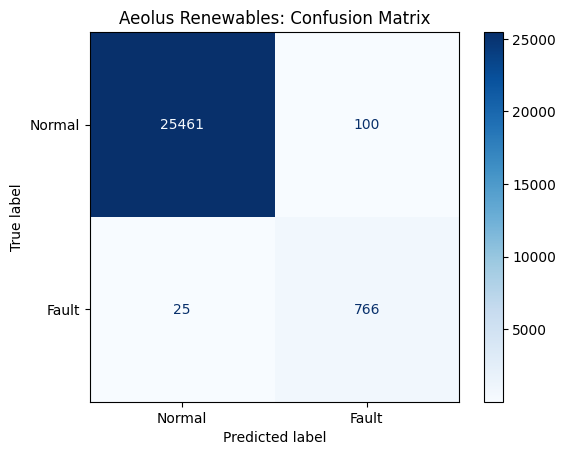

-> Visual asset saved successfully as: confusion_matrix.png


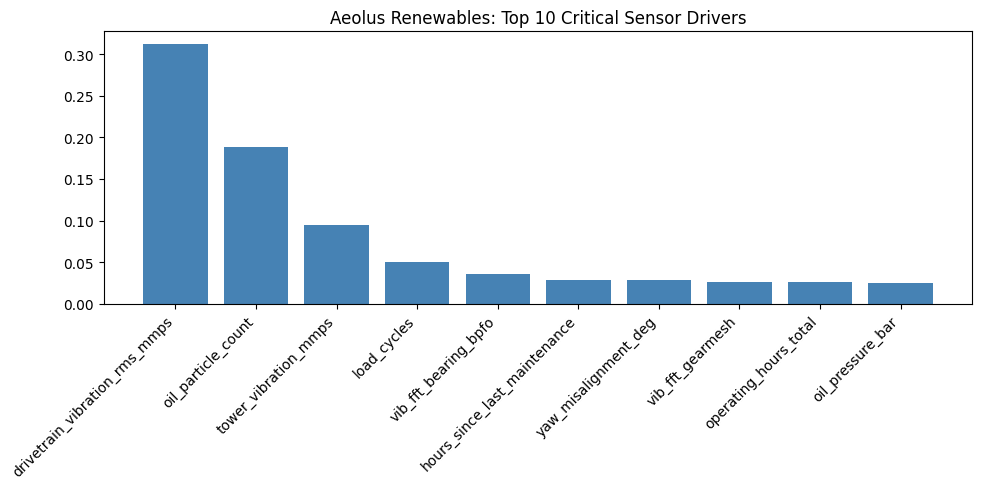

-> Visual asset saved successfully as: feature_importance.png


In [8]:
# ==========================================================
# STEP 1: IMPORT STABLE PACKAGES & LOAD TURBINE DATA
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset using your exact file path with the browser suffix
df = pd.read_csv('/content/wind_turbine_detection (2).csv')

# ==========================================================
# STEP 2: DOMAIN ENGINEERING & DATA CLEANSING
# ==========================================================
# Drop metadata columns to prevent data leakage and overfitting
drop_cols = ['timestamp', 'turbine_id']
if 'rated_power_kW' in df.columns and df['rated_power_kW'].nunique() == 1:
    drop_cols.append('rated_power_kW')

X = df.drop(columns=drop_cols + ['failure'])
y = df['failure']

# Create Domain Features: Thermal Deviation (Friction Indicator)
if 'main_bearing_temp_C' in X.columns and 'ambient_temp_C' in X.columns:
    X['thermal_deviation_bearing'] = X['main_bearing_temp_C'] - X['ambient_temp_C']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize continuous sensor values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# STEP 3: TRAIN OPTIMISED MODEL (TUNED FOR RECALL)
# ==========================================================
print("--- Training Balanced Predictive Maintenance Model ---")
# Use class_weight='balanced' to prioritize finding the rare 'failure' events
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# ==========================================================
# STEP 4: GENERATE RESULTS & CERTIFICATION PORTFOLIO ASSETS
# ==========================================================
# Generate predictions using an aggressive probability threshold to prioritize Recall
y_prob = model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.35  # Alert early to catch degrading components before they break
y_pred = (y_prob >= threshold).astype(int)

print("\n--- Project Performance Metrics ---")
print(classification_report(y_test, y_pred))

# Visual 1: Save Confusion Matrix Chart
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fault'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Aeolus Renewables: Confusion Matrix')
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("-> Visual asset saved successfully as: confusion_matrix.png")

# Visual 2: Save Sensor Feature Importance Chart
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Get top 10 sensors
plt.figure(figsize=(10, 5))
plt.title("Aeolus Renewables: Top 10 Critical Sensor Drivers")
plt.bar(range(10), importances[indices], align="center", color='steelblue')
plt.xticks(range(10), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("-> Visual asset saved successfully as: feature_importance.png")